# Example-14: Estimation of linear invariants

In [1]:
# Import

import numpy
import pandas
import torch

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [3]:
# Given measured amplitudes and model (or measured) twiss parameters, invariants at each monitor location can be estimated
# Weighted average can be performed to estimate global invariant values and errors
# Twiss and invariant values can be estimated from TbT data
# Given measured twiss and orbits, invariant values can be estimated

In [4]:
# Set model with errors

model = Model(path='../config.yaml', dtype=dtype, device=device)

# Set errors

model.make_error(1.0E-3, 0.5E-3, length=0.01)

# Set transport

model.make_transport(error=True, exact=False)

# Compute twiss (not used in generation of trajectories)

model.make_twiss()
print(model.is_stable)

# Set fractional tunes

mqx, mqy = model.out_tune_fractional

True


torch.Size([54, 1024, 4])

4.869140134e-07, 3.571136509e-21
1.488519407e-07, 7.006084857e-20



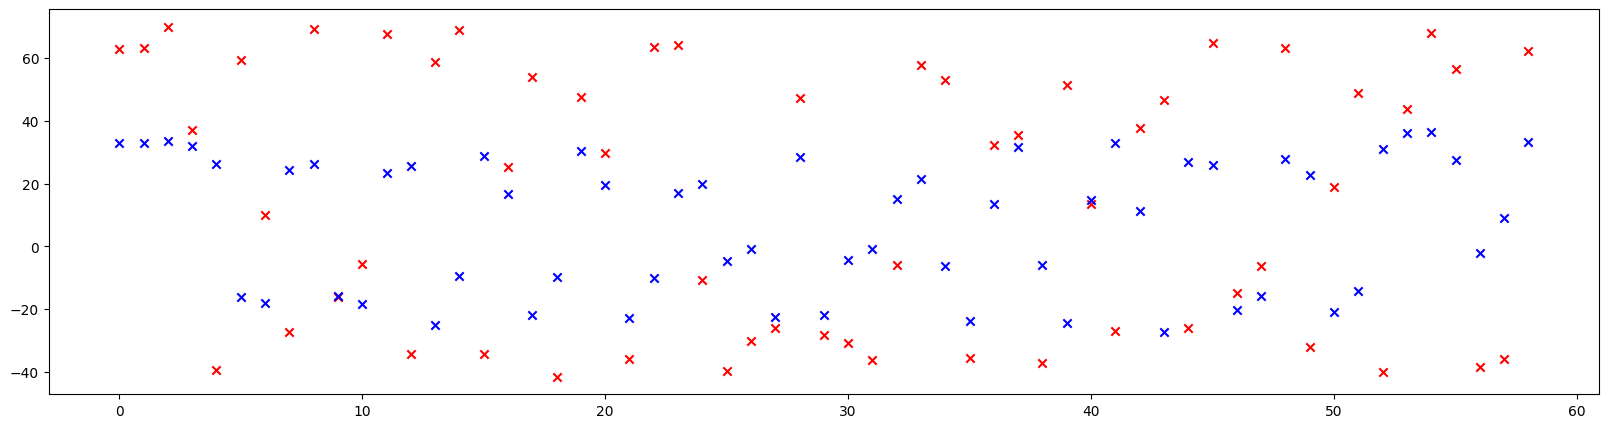

tensor(1.821303351825e+02, dtype=torch.float64)
tensor(1.674480647601e+02, dtype=torch.float64)



In [5]:
# Generate test trajectories

# Set initial condition

initial = torch.tensor([0.002, 0.0, 0.002, 0.0], dtype=dtype, device=device)

# Set number of iterations

length = 2**10

# Generate trajectories

trajectory =  model.make_trajectory(initial, length, error=True, transport=True)[model.monitor_index]
print(trajectory.shape)
print()

# Set x & y coordinates at each monitor location

x = trajectory[..., 0]
y = trajectory[..., 2]

# Compute reference invariant values using selected trajectory

# Set trajectory index

index = 0

# Compute invariants

from harmonica.parameterization import invariant
action_x, action_y = invariant(model.out_normal[model.monitor_index[index]], trajectory[index])

print(f'{action_x.mean().item():>12.9e}, {action_x.std().item():>12.9e}')
print(f'{action_y.mean().item():>12.9e}, {action_y.std().item():>12.9e}')
print()

action_x = action_x.mean()
action_y = action_y.mean()

# Compare model and real beta function values

from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

cs_ax, cs_bx, cs_ay, cs_by = torch.stack([wolski_to_cs(w) for w in normal_to_wolski(model.out_normal)]).T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.size), 100*(cs_bx - model.bx)/model.bx, color='red', marker='x')
plt.scatter(range(model.size), 100*(cs_by - model.by)/model.by, color='blue', marker='x')
plt.show()

error_x = (cs_bx[model.monitor_index] - model.bx[model.monitor_index]).abs().sum()
error_y = (cs_by[model.monitor_index] - model.by[model.monitor_index]).abs().sum()

print(error_x)
print(error_y)
print()

In [6]:
# Set free normalization matrix elements

N11 = model.out_normal[:, 0, 0][model.monitor_index]
N33 = model.out_normal[:, 2, 2][model.monitor_index]
N21 = model.out_normal[:, 1, 0][model.monitor_index]
N43 = model.out_normal[:, 3, 2][model.monitor_index]
N13 = model.out_normal[:, 0, 2][model.monitor_index]
N31 = model.out_normal[:, 2, 0][model.monitor_index]
N14 = model.out_normal[:, 0, 3][model.monitor_index]
N41 = model.out_normal[:, 3, 0][model.monitor_index]

# Using eight free elements other elements of normalization matrix can be computed from symplectic condition
# Note, N12 and N34 are fixed to zero values

from harmonica.parameterization import parametric_normal
print(torch.allclose(model.out_normal[model.monitor_index], torch.stack([parametric_normal(*free) for free in torch.stack([N11, N33, N21, N43, N13, N31, N14, N41]).T])))

True


In [7]:
# Generate TbT data

# Set noise values for each monitor location 

noise_x = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
noise_y = 1.0E-6*(5.0 + 5.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

# Set window

win = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

# Set TbT & add noise

X = Data.from_data(win, x)
X.add_noise(noise_x)
X.data.copy_(X.work)
X.reset()
print(X)

Y = Data.from_data(win, y)
Y.add_noise(noise_y)
Y.data.copy_(Y.work)
Y.reset()
print(Y)

Data(54, Window(1024, 'cosine_window', 1.0))
Data(54, Window(1024, 'cosine_window', 1.0))


In [8]:
# Compute frequency, amplitude and phase for x plane

# Estimate noise

flt = Filter(X)
_, sigma_x = flt.estimate_noise()

# Estimate (main) frequency

from harmonica.statistics import trimmed_mean
from harmonica.statistics import trimmed_variance
f = Frequency(X)
X.window_remove_mean()
X.window_apply()
f('parabola')
X.reset()
nux, sigma_nux = 1.0 - trimmed_mean(f.frequency, min_fraction=0.05, max_fraction=0.05), trimmed_variance(f.frequency, min_fraction=0.05, max_fraction=0.05).sqrt()
print(f'mqx={mqx.item():12.9}')
print(f'nux={nux.item():12.9}, sigma_nux={sigma_nux.item():12.9}, error_nux={abs(mqx - nux).item():12.9}')

# Filter data

flt.filter_svd(rank=4)
flt.filter_hankel(rank=4, random=True, buffer=16, count=16)

# Estimate amplitude & phase

dx = Decomposition(X)

axx, sigma_axx, _ = dx.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')
fxx, sigma_fxx, _ = dx.harmonic_phase(nux, length=512, order=0.0, error=True, sigma_frequency=sigma_nux, shift=True, count=256, step=8, method='noise')

mqx= 0.562554979
nux= 0.562554947, sigma_nux=1.05319889e-07, error_nux=3.24666464e-08


In [9]:
# Compute frequency, amplitude and phase for y plane

# Estimate noise

flt = Filter(Y)
_, sigma_y = flt.estimate_noise()

# Estimate (main) frequency

from harmonica.statistics import trimmed_mean
from harmonica.statistics import trimmed_variance
f = Frequency(Y)
Y.window_remove_mean()
Y.window_apply()
f('parabola')
Y.reset()
nuy, sigma_nuy = 1.0 - trimmed_mean(f.frequency, min_fraction=0.05, max_fraction=0.05), trimmed_variance(f.frequency, min_fraction=0.05, max_fraction=0.05).sqrt()
print(f'mqy={mqy.item():12.9}')
print(f'nuy={nuy.item():12.9}, sigma_nuy={sigma_nuy.item():12.9}, error_nuy={abs(mqy - nuy).item():12.9}')

# Filter data

flt.filter_svd(rank=4)
flt.filter_hankel(rank=4, random=True, buffer=16, count=16)

# Estimate amplitude & phase

dy = Decomposition(Y)

ayy, sigma_ayy, _ = dy.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
fyy, sigma_fyy, _ = dy.harmonic_phase(nuy, length=512, order=0.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=256, step=8, method='noise')

mqy= 0.632426947
nuy= 0.632426924, sigma_nuy=1.10558868e-07, error_nuy=2.31541553e-08


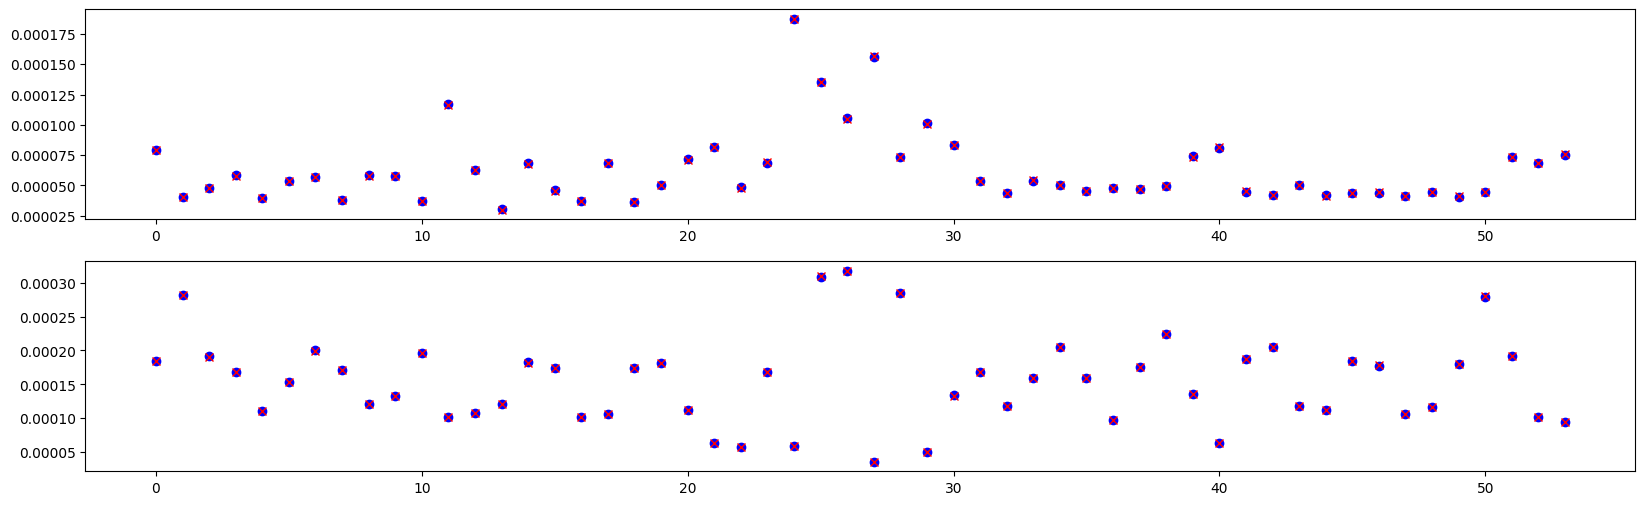

In [10]:
# Compute & plot coupled amplitudes

axy, sigma_axy, _ = dx.harmonic_amplitude(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nuy, shift=True, count=64, step=8, method='noise')
ayx, sigma_ayx, _ = dy.harmonic_amplitude(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=8, method='noise')

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), axy.cpu().numpy(), yerr=sigma_axy.cpu().numpy(), fmt=' ', color='red', marker='x')
ax.scatter(range(model.monitor_count), ((N13**2 + N14**2)*2*action_y).sqrt(), color='blue', marker='o')

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), ayx.cpu().numpy(), yerr=sigma_ayx.cpu().numpy(), fmt=' ', color='red', marker='x')
ax.scatter(range(model.monitor_count), ((N31**2 + N14**2*N33**2/N11**2)*2*action_x).sqrt(), color='blue', marker='o')

plt.show()

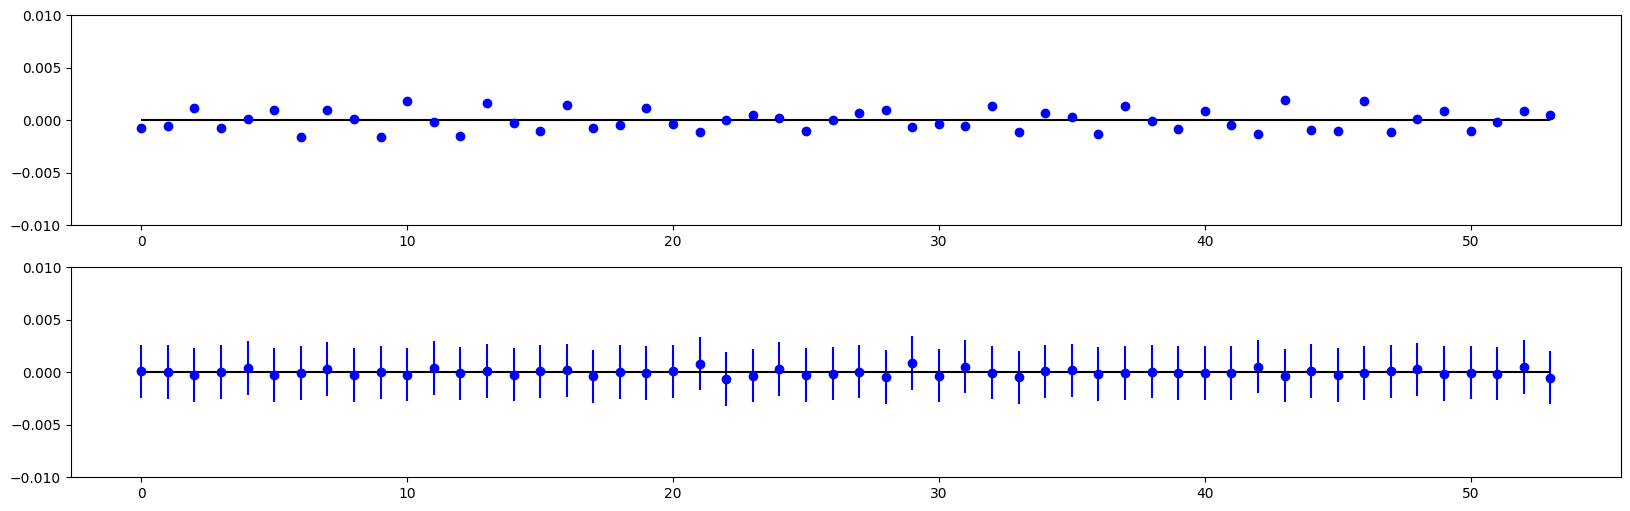

In [11]:
# Set table

table = Table(
    [name for name, kind in zip(model.name, model.kind) if kind == 'MONITOR'],
    nux, nuy, axx, ayy, fxx, fyy, sigma_nux, sigma_nuy, sigma_axx, sigma_ayy, sigma_fxx, sigma_fyy,
    x=X.work,
    y=Y.work,
    dtype=dtype, device=device)

# Compare phase advance between adjacent monitor locations

mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(mqx, mux)
muy, _ = Decomposition.phase_adjacent(mqy, muy)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x).cpu().numpy(), yerr=table.sigma_x.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y).cpu().numpy(), yerr=table.sigma_y.cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax.set_ylim(-1.0E-2, +1.0E-2)

plt.show()

In [12]:
# Set twiss 

twiss = Twiss(model, table, limit=4)

In [13]:
# Estimate twiss from amplitude

twiss.get_action()
twiss.get_twiss_from_amplitude()

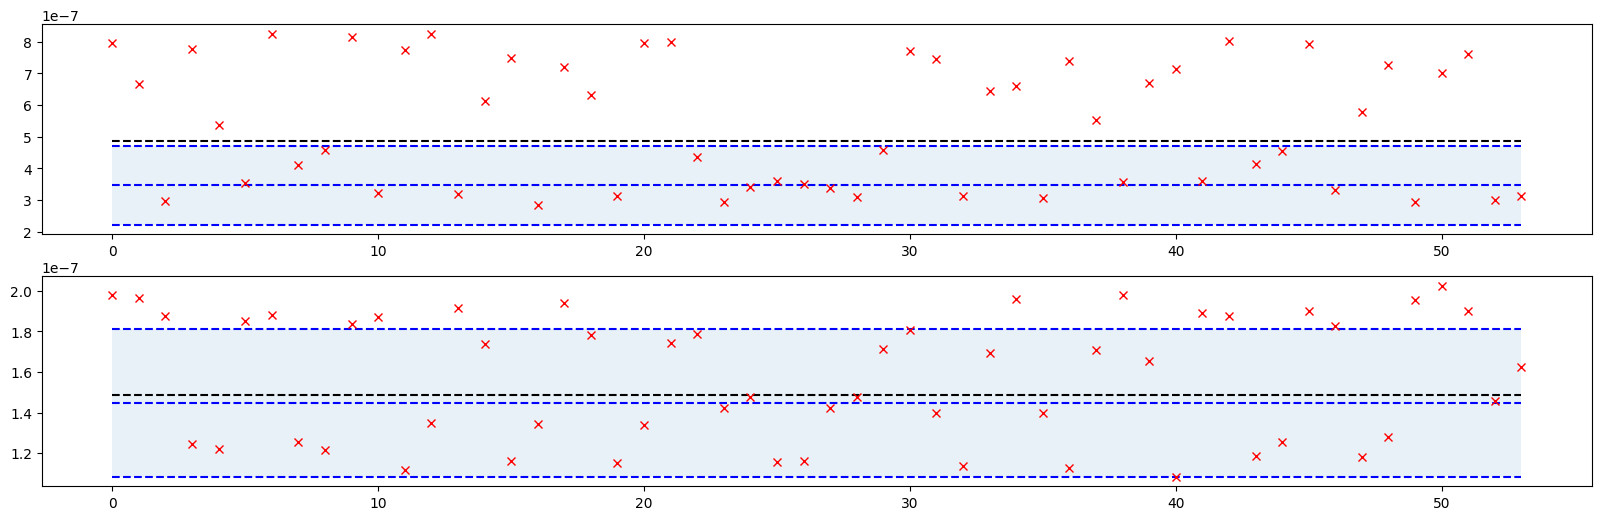

[4.86914013e-07 3.45873737e-07 1.24195956e-07]
[1.48851941e-07 1.44870537e-07 3.65102597e-08]


In [14]:
# Plot actions (estimated using amplitude and model twiss parameters)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.hlines([action_x.cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='black')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='blue')
ax.fill_between(range(model.monitor_count), (twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy(), alpha=0.1)

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.hlines([action_y.cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='black')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='blue')
ax.fill_between(range(model.monitor_count), (twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy(), alpha=0.1)

plt.show()

print(torch.stack([action_x, twiss.action['center_jx'], twiss.action['spread_jx']]).cpu().numpy())
print(torch.stack([action_y, twiss.action['center_jy'], twiss.action['spread_jy']]).cpu().numpy())

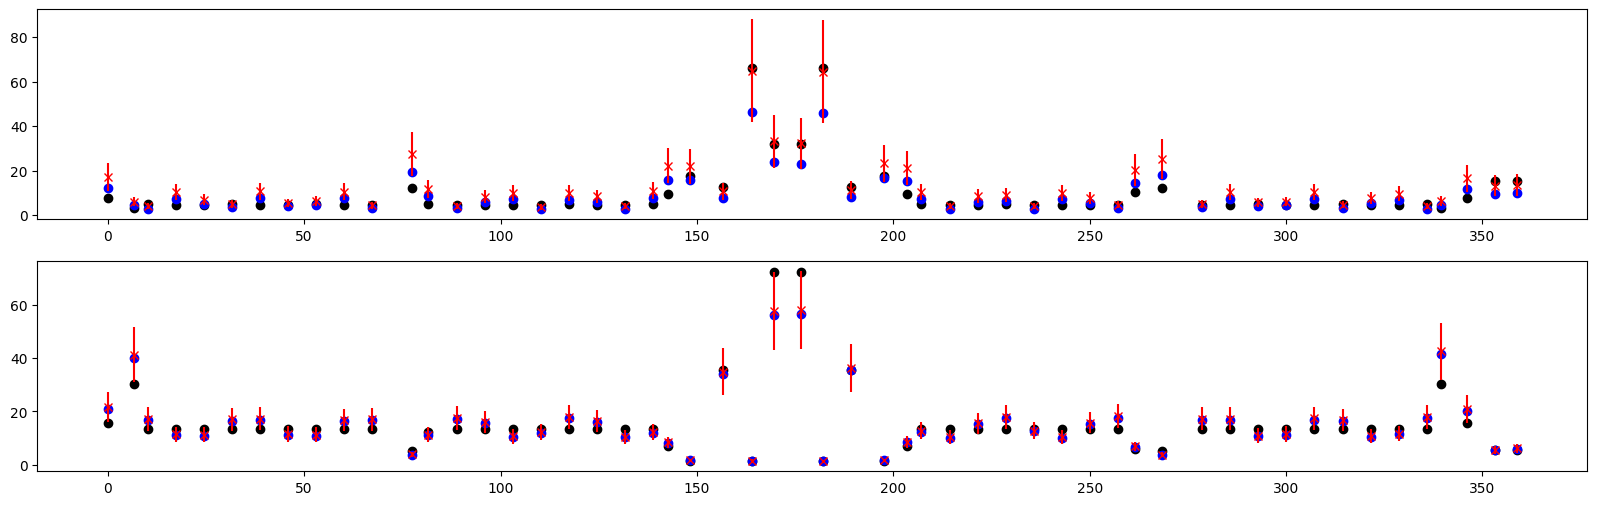

tensor(2.042110624134e+02, dtype=torch.float64)
tensor(2.312554365003e+01, dtype=torch.float64)


In [15]:
# Plot twiss

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

print((cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum())
print((cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum())

In [16]:
# Estimate twiss from phase

twiss.phase_virtual()
twiss.get_twiss_from_phase()

mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
twiss.process_twiss(plane='x', mask=mask_x, weight=True) ;

mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': True, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
twiss.process_twiss(plane='y', mask=mask_y, weight=True) ;

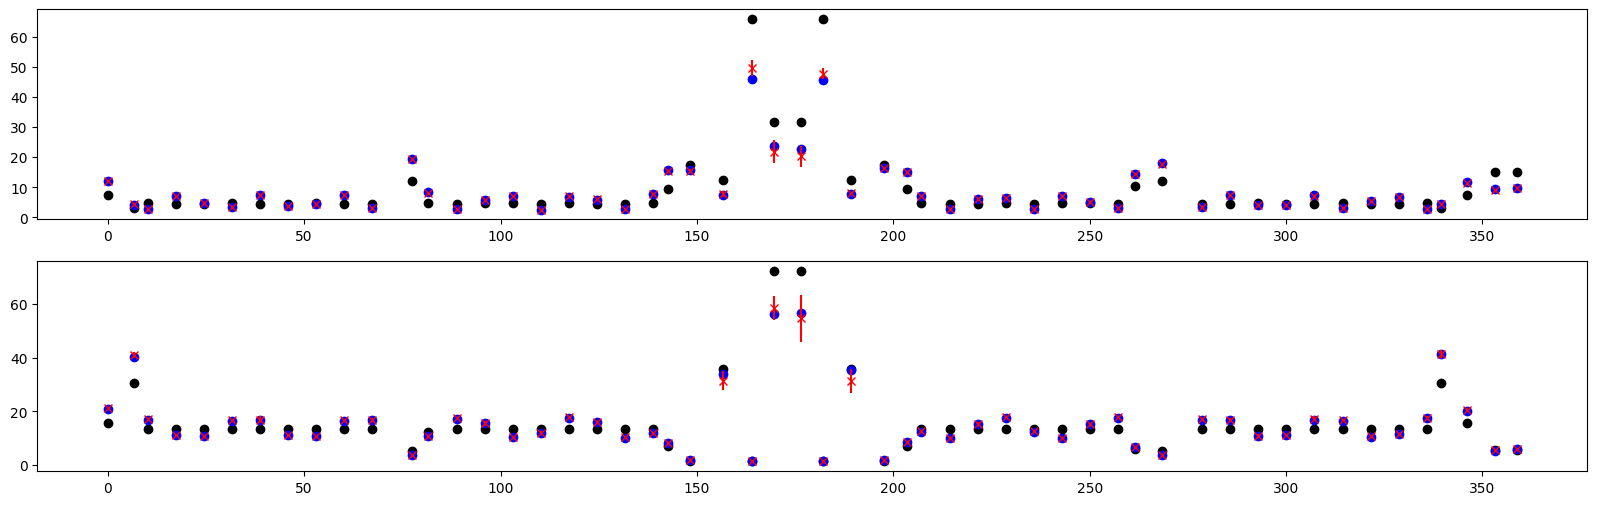

tensor(1.214284235277e+01, dtype=torch.float64)
tensor(1.864026544523e+01, dtype=torch.float64)


In [17]:
# Plot twiss

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.bx[model.monitor_index].cpu().numpy(), yerr=twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.by[model.monitor_index].cpu().numpy(), yerr=twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

print((cs_bx[model.monitor_index] - twiss.bx[model.monitor_index]).abs().sum())
print((cs_by[model.monitor_index] - twiss.by[model.monitor_index]).abs().sum())

In [18]:
# Estimate twiss from amplitude (use twiss from phase for action estimation)

twiss.get_action(bx=twiss.bx[model.monitor_index],
                 by=twiss.by[model.monitor_index],
                 sigma_bx=twiss.sigma_bx[model.monitor_index],
                 sigma_by=twiss.sigma_by[model.monitor_index])

twiss.get_twiss_from_amplitude()

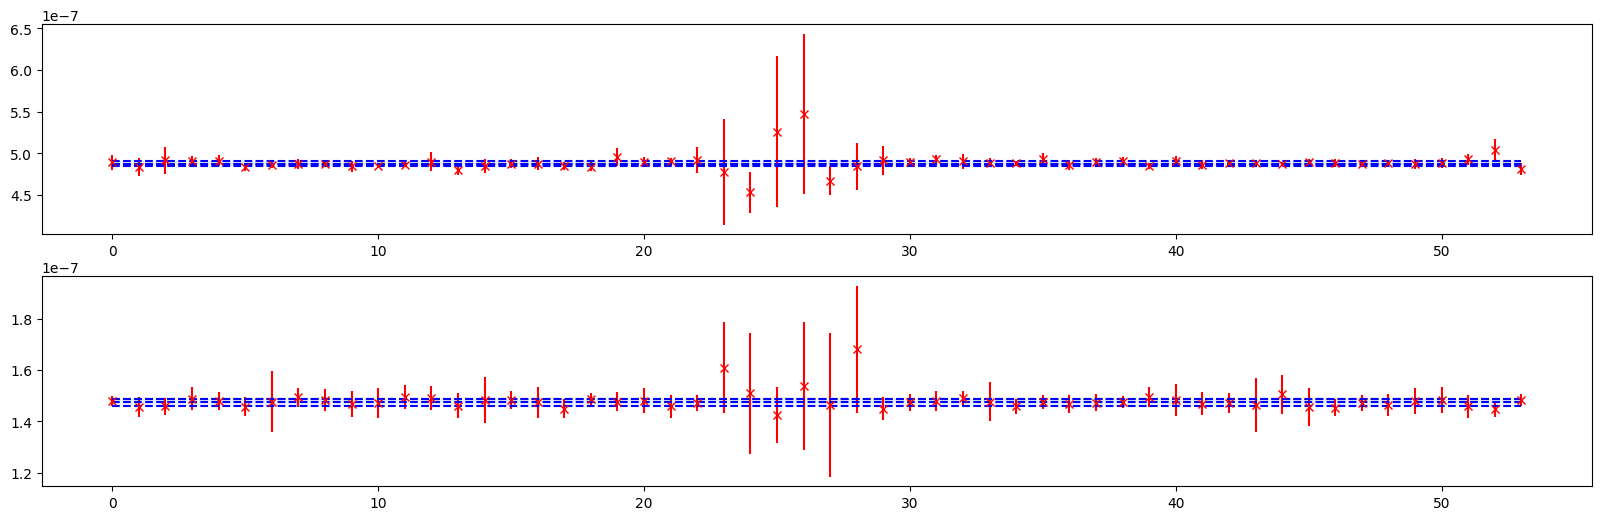

[4.86914013e-07 4.87739537e-07 2.63629615e-09]
[1.48851941e-07 1.47364713e-07 1.32043064e-09]


In [19]:
# Plot actions (estimated using amplitude and model twiss parameters)

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.hlines([action_x.cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='black')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='blue')
ax.fill_between(range(model.monitor_count), (twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy(), alpha=0.1)

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.hlines([action_y.cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='black')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='blue')
ax.fill_between(range(model.monitor_count), (twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy(), alpha=0.1)

plt.show()

print(torch.stack([action_x, twiss.action['center_jx'], twiss.action['spread_jx']]).cpu().numpy())
print(torch.stack([action_y, twiss.action['center_jy'], twiss.action['spread_jy']]).cpu().numpy())

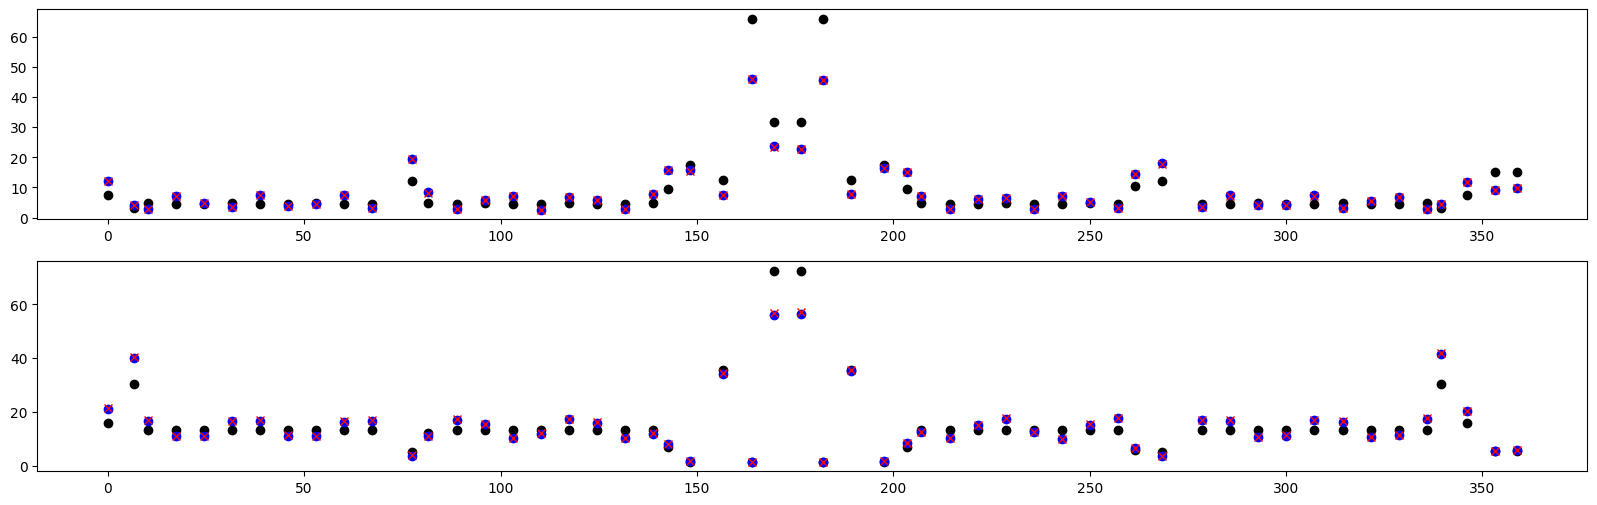

tensor(8.598861724690e-01, dtype=torch.float64)
tensor(8.497364145982e+00, dtype=torch.float64)


In [20]:
# Plot twiss

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['bx'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), twiss.data_amplitude['by'].cpu().numpy(), yerr=twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

print((cs_bx[model.monitor_index] - twiss.data_amplitude['bx']).abs().sum())
print((cs_by[model.monitor_index] - twiss.data_amplitude['by']).abs().sum())

In [21]:
%%time

# Estimate twiss from invariant fit (use first 256 turns and 128 random samples)

from harmonica.parameterization import parametric_normal
data = twiss.get_twiss_from_data(1,
                                 256, 
                                 parametric_normal,
                                 model.matrix,
                                 twiss=None, 
                                 method='pair', 
                                 limit=1, 
                                 product=True, 
                                 jacobian=False, 
                                 count=128, 
                                 fraction=0.75, 
                                 ix=None, 
                                 iy=None, 
                                 n_jobs=12, 
                                 verbose=False)
print(data.shape)

torch.Size([54, 2, 10, 128])
CPU times: user 39.3 s, sys: 1.9 s, total: 41.2 s
Wall time: 50.3 s


In [22]:
# Process fitted invariants

ix = data[:, 0, 0]
iy = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix, iy, sigma_ix, sigma_iy)

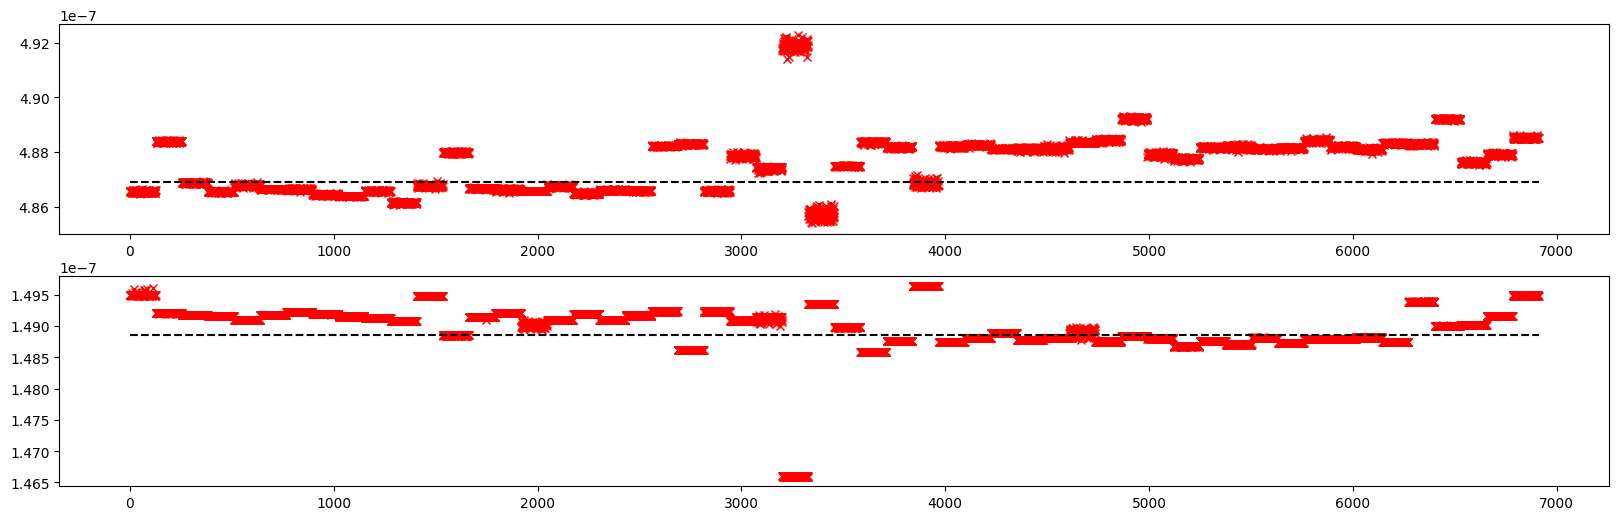

In [23]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(54*128), ix.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
ax.hlines(action_x, 0, 54*128, linestyles='dashed', color='black',  zorder=1)

ax = plt.subplot(212)
ax.errorbar(range(54*128), iy.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
ax.hlines(action_y, 0, 54*128, linestyles='dashed', color='black',  zorder=1)

plt.show()

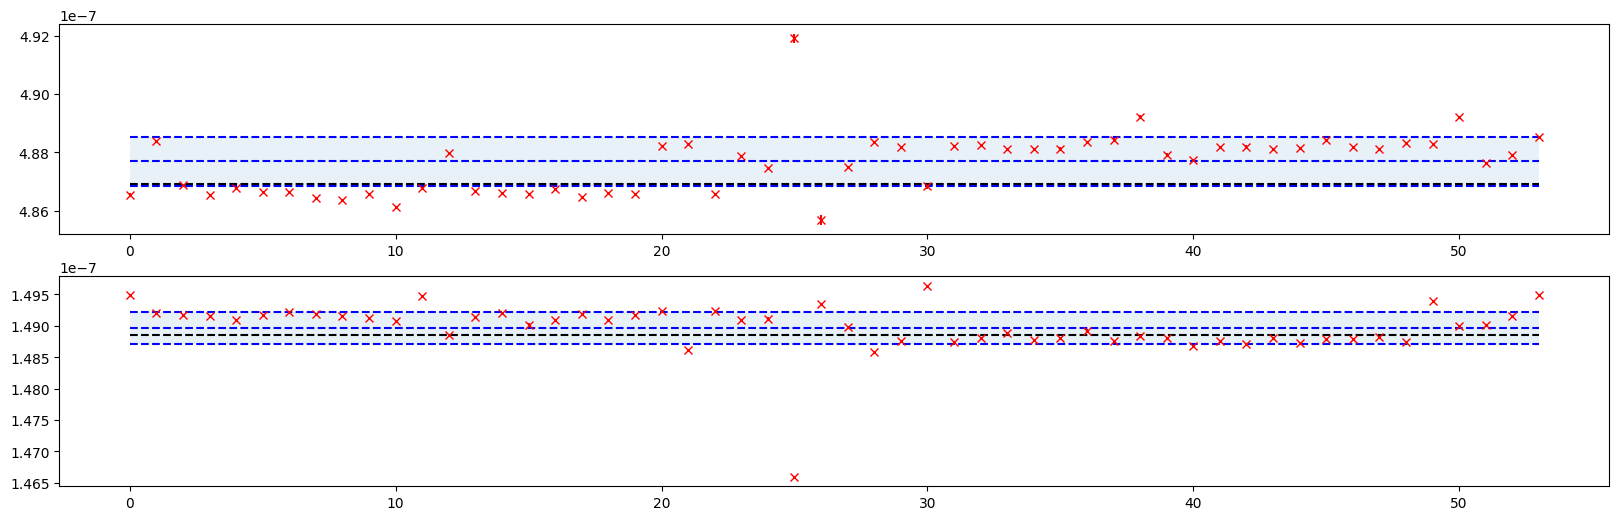

[4.86914013e-07 4.87739537e-07 2.63629615e-09]
[1.48851941e-07 1.47364713e-07 1.32043064e-09]

[4.86914013e-07 4.87698416e-07 8.39302339e-10]
[1.48851941e-07 1.48965228e-07 2.52453563e-10]



In [24]:
# Plot invariants for each signal

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), invariant['ix_center'].cpu().numpy(), yerr=invariant['ix_spread'].cpu().numpy(), fmt=' ', color='red', marker='x')
ax.hlines(action_x.cpu().numpy(), 0, model.monitor_count - 1, linestyles='dashed', color='black')
ax.hlines([(invariant['ix_value'] - invariant['ix_error']).cpu().numpy(), invariant['ix_value'].cpu().numpy(), (invariant['ix_value'] + invariant['ix_error']).cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='blue')
ax.fill_between(range(model.monitor_count), (invariant['ix_value'] - invariant['ix_error']).cpu().numpy(), (invariant['ix_value'] + invariant['ix_error']).cpu().numpy(), alpha=0.1)

ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), invariant['iy_center'].cpu().numpy(), yerr=invariant['iy_spread'].cpu().numpy(), fmt=' ', color='red', marker='x')
ax.hlines(action_y.cpu().numpy(), 0, model.monitor_count - 1, linestyles='dashed', color='black')
ax.hlines([(invariant['iy_value'] - invariant['iy_error']).cpu().numpy(), invariant['iy_value'].cpu().numpy(), (invariant['iy_value'] + invariant['iy_error']).cpu().numpy()], 0, model.monitor_count - 1, linestyles='dashed', color='blue')
ax.fill_between(range(model.monitor_count), (invariant['iy_value'] - invariant['iy_error']).cpu().numpy(), (invariant['iy_value'] + invariant['iy_error']).cpu().numpy(), alpha=0.1)

plt.show()

print(torch.stack([action_x, twiss.action['center_jx'], twiss.action['spread_jx']]).cpu().numpy())
print(torch.stack([action_y, twiss.action['center_jy'], twiss.action['spread_jy']]).cpu().numpy())
print()

print(torch.stack([action_x, invariant['ix_value'], invariant['ix_error']]).cpu().numpy())
print(torch.stack([action_y, invariant['iy_value'], invariant['iy_error']]).cpu().numpy())
print()

In [25]:
# Process twiss parameters

mask = invariant['ix_mask']*invariant['sx_mask']*invariant['iy_mask']*invariant['sy_mask']

*_, value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41 = data[:, 0].swapaxes(0, 1)
*_, error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41 = data[:, 1].swapaxes(0, 1)

value_n11, error_n11 = twiss.process(value_n11, error_n11, mask=mask)
value_n33, error_n33 = twiss.process(value_n33, error_n33, mask=mask)
value_n21, error_n21 = twiss.process(value_n21, error_n21, mask=mask)
value_n43, error_n43 = twiss.process(value_n43, error_n43, mask=mask)
value_n13, error_n13 = twiss.process(value_n13, error_n13, mask=mask)
value_n31, error_n31 = twiss.process(value_n31, error_n31, mask=mask)
value_n14, error_n14 = twiss.process(value_n14, error_n14, mask=mask)
value_n41, error_n41 = twiss.process(value_n41, error_n41, mask=mask)

out_value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
out_error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

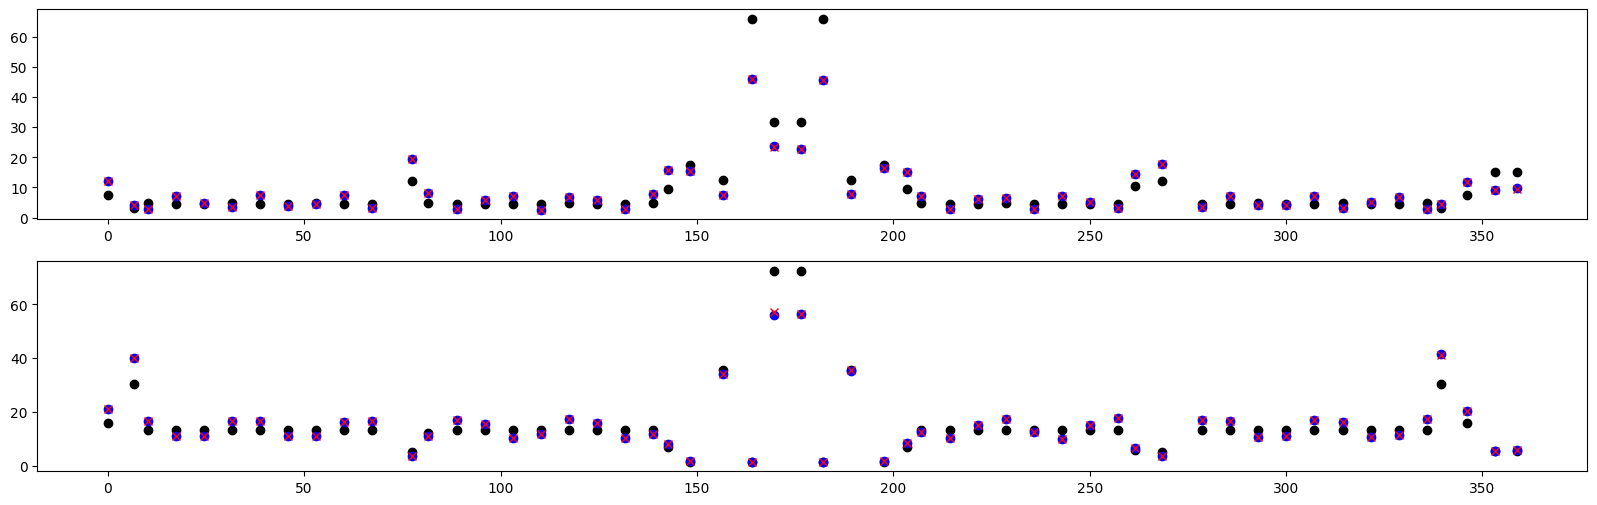

tensor(1.006411160445e+00, dtype=torch.float64)
tensor(2.232584620402e+00, dtype=torch.float64)


In [26]:
# Compute CS twiss

from harmonica.parameterization import parametric_normal
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs

cs_value, cs_error = [], []

for value, error in zip(out_value, out_error):
    local = value.reshape(-1, 1) + error.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    local = torch.stack([parametric_normal(*free) for free in local.T])
    local = normal_to_wolski(local)
    local = torch.stack([wolski_to_cs(wolski) for wolski in local]).T
    cs_value.append(local.mean(-1))
    cs_error.append(local.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

plt.figure(figsize=(20, 3*2))

ax = plt.subplot(211)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_bx[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_bx.cpu().numpy(), yerr=error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')

ax = plt.subplot(212)
ax.scatter(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), marker='o', color='black')
ax.scatter(model.time[model.monitor_index].cpu().numpy(), cs_by[model.monitor_index].cpu().numpy(), marker='o', color='blue')
ax.errorbar(model.time[model.monitor_index].cpu().numpy(), value_by.cpu().numpy(), yerr=error_by.cpu().numpy(), fmt=' ', marker='x', color='red')

plt.show()

print((cs_bx[model.monitor_index] - value_bx).abs().sum())
print((cs_by[model.monitor_index] - value_by).abs().sum())

In [27]:
# Compute orbits at each monitor location

limit = 2
orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, limit, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([54, 4, 256])


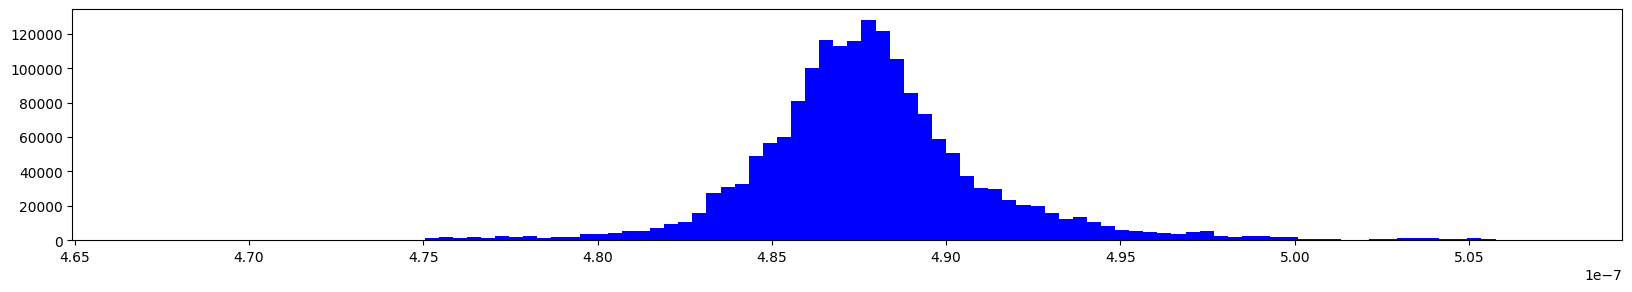

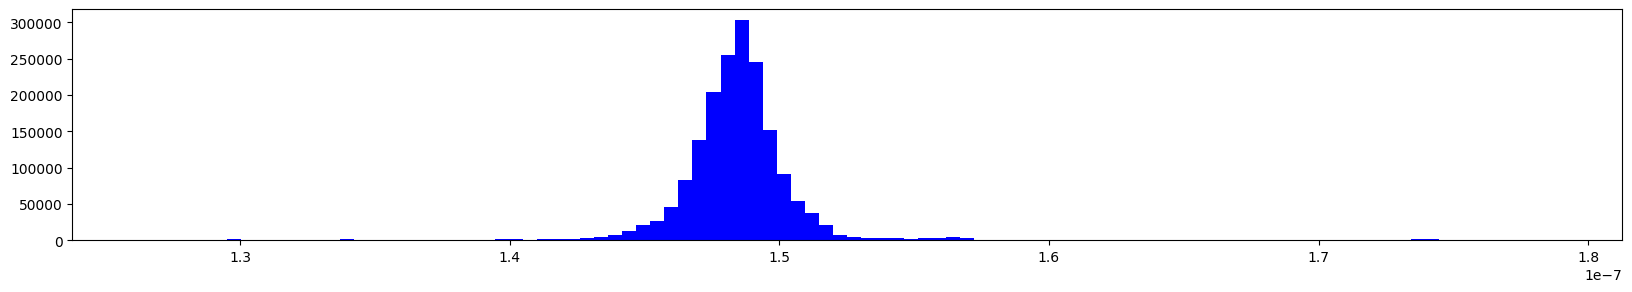

In [28]:
# Use measured twiss to estimate invariants

n11, n33, n21, n43, n13, n31, n14, n41 = out_value.T
e11, e33, e21, e43, e13, e31, e14, e41 = out_error.T

BAG_IX = []
BAG_IY = []
for location in range(model.monitor_count):
    for _ in range(128):
        m11 = n11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = n33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = n21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = n43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = n13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = n31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = n14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = n41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        BAG_IX.append(IX)
        BAG_IY.append(IY)
BAG_IX = torch.stack(BAG_IX).flatten()
BAG_IY = torch.stack(BAG_IY).flatten()

from harmonica.statistics import standardize
from harmonica.statistics import median, biweight_midvariance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.anomaly import threshold


factor = torch.tensor(5.0, dtype=dtype, device=device)

data_x = standardize(BAG_IX, center_estimator=median, spread_estimator=biweight_midvariance)
mask_x = threshold(data_x, -factor, +factor).squeeze()
value_x = weighted_mean(BAG_IX, weight=mask_x)
error_x = weighted_variance(BAG_IX, weight=mask_x).sqrt()

data_y = standardize(BAG_IY, center_estimator=median, spread_estimator=biweight_midvariance)
mask_y = threshold(data_y, -factor, +factor).squeeze()
value_y = weighted_mean(BAG_IY, weight=mask_y)
error_y = weighted_variance(BAG_IY, weight=mask_y).sqrt()

plt.figure(figsize=(20, 3))
plt.hist(BAG_IX.cpu().numpy(), bins=100, range=(BAG_IX.min().item(), BAG_IX.max().item()), color='blue')
plt.show()

plt.figure(figsize=(20, 3))
plt.hist(BAG_IY.cpu().numpy(), bins=100, range=(BAG_IY.min().item(), BAG_IY.max().item()), color='blue')
plt.show()

In [29]:
# Compare invariant estimations

print(torch.stack([action_x, twiss.action['center_jx'], twiss.action['spread_jx']]).cpu().numpy())
print(torch.stack([action_x, invariant['ix_value'], invariant['ix_error']]).cpu().numpy())
print(torch.stack([action_x, value_x, error_x]).cpu().numpy())
print()

print(torch.stack([action_y, twiss.action['center_jy'], twiss.action['spread_jy']]).cpu().numpy())
print(torch.stack([action_y, invariant['iy_value'], invariant['iy_error']]).cpu().numpy())
print(torch.stack([action_y, value_y, error_y]).cpu().numpy())
print()

[4.86914013e-07 4.87739537e-07 2.63629615e-09]
[4.86914013e-07 4.87698416e-07 8.39302339e-10]
[4.86914013e-07 4.87755318e-07 3.18351545e-09]

[1.48851941e-07 1.47364713e-07 1.32043064e-09]
[1.48851941e-07 1.48965228e-07 2.52453563e-10]
[1.48851941e-07 1.48414407e-07 1.56902282e-09]

